## AY25-26 Term 2 CS421 Group Project

### Data and Task

In this project, you will be working with data extracted from a recommender systems type dataset: you are provided with a large set of interactions between subjects (e.g., online shopping users, or social network users)  and items (e.g., shopping items, books, songs, or movies). Whenever a user "interacts" with an item, he/she has some experience the item (e.g., purchase the items, read the book, listen the songs, or watch the movie) and gives a mark or "rating" between 0 and 5 stars (5 stars indicating the best experience, and 1 or 0 stars indicating that the user didn't like the experience at all). 

In this exercise, we will **not** be performing the recommendation task per se. Instead, we will identify *anomalous users*. In the dataset that you are provided with, some of the data was corrupted. Whilst most of the data comes from real life user-item interactions from a real-world application, some "users" are anomalous: they were generated by me according to some undisclosed procedure to simulate exceptional users with unexpected interactions. Most users have normal, expected interactions in real applications, so the anomalous users only account for a very small proportion of the users. Thus, identifying those anomalous users are important to the application, but it can be very challenging.

You are provided with two data frames: the first one ("X") contains the interactions provided to you, and the second one ("y") contains the labels for the users. There is a set of 1,000 unique items the users interact with, ranging from item ID of 0 to item ID 999, which is fixed throughout the competition. Note that it is not necessarily that all items appear in one set of data samples given during the competition, meaning that some of the items may not be rated by any user in a user set within a specific period of time.

As you can see, the three columns in "ratings" correspond to the user ID, the item ID and the rating. Thus, each row of "ratings" contains a single interaction. For instance, if the row "142, 152, 5" is present, this means that the user with ID 142 has given the movie 152 the rating 5 stars.

The dataframe "labels" has two columns. In the first column we have the user ids, whilst the second column contains the labels. A label of 1 indicates that the user is 'anomalous', whilst a label of 0 denotes a natural, normal user (coming from real life interactions). 

For instance, if the labels matrix contains the line "142, 1", it means that all of the ratings given by the user with id 142 is an anomalous user. This means all lines in the dataframe "ratings" which start with the userID 142 correspond to fake interactions. 

### Evaluation

Your task is to be able to classify unseen instances as either anomalies or non anomalies. 

There are **far more** normal users than anomalies in the dataset, which makes this a very heavily **unbalanced dataset**. Thus, accuracy will not be a good measure of performance, since simply predicting that every user is normal will give good accuracy. Thus, we need to use some other evaluation metrics (see slides and lecture note from week 3). 

Suitable **EVALUATION METRICS** include: **AUC** (AREA UNDER CURVE), **PRECISION**, **RECALL**, and **F1 score**. The **main metric** will be the **AREA UNDER CURVE**, and it will by default be used to rank teams. This means your programs should return an **anomaly score** for each user (the higher the score, the more likely the model think the sample is anomalous).  

Before Week 9, each team is required to develop a model using the data `training_data_with_labels.npz` that contains labeled data. You can leverage the data in whatever the way you believe is right. Thereafter every week, we will evaluate the performance of each team's model on an *unseen test set* I will provide, in terms of AUC, and rank the teams by **AUC**. We will release the class labels for the test dataset after we finalize the ranking for each week. Each team then can utilize this newly released class labels (together with the previously released labeled data) to develop a better model.

The difficulty implied by **the generation procedure of the anomalies WILL CHANGE as the project evolves: depending on how well the teams are doing, I will generate easier or harder anomalies**.

The **first round of competition** will take place after recess (week 9): this means that I will **release the first test set on the Thursday of week 9**, and you must submit at least one valid set of anomaly scores to **Codabench** before the **Wednesday of week 10 at 11:59 PM**. Your submission will be **a .npz file** (check the exemplar file attached and the code below that generates the .npz file for detail). We will then look at the results together during Thursday's class. Each group will be limited to no more than **THREE submissions per week**. The best result is taken to rank in the leaderboard.  

We will check everyone's performance in this way every week (once on  week 10, once on week 11, and once on week 12). 

Whilst performance (expressed in terms of AUC and your ranking compared to other teams) at **each of the check points** (weeks 9 to 12 inclusive) is an **important component** of your **final grade**, the **project report** and the detail of the various methods you will have tried will **also** be very **important**. Ideally, to get perfect marks (A+) for this component, you should try at least **two supervised methods** and **one unsupervised methods**, as well as be ranked among the **best teams (top 3)** in terms of performance. 

For the project report, I will be especially interested in your analysis and reasoning. High marks will be given to any team that is able to qualitatively and quantitatively analyze the performance of different versions of your models, delivering convincing empirical justification about why the models behave in a particular way. Exemplar qualitative analyses include visualization of feature representations learned in hidden layers, distribution of anomaly scores for the two classes, reasoning over typical failure and correct cases, etc. In terms of quantitative analysis, in addition to general AUC performance of your overall models, other useful quantitative results may include ablation study (i.e., how each component of your model contributes to the overall performance), hyperparameter sensitivity analysis, analysis of computational cost, etc.


The performance part of the grading will be based the leaderboard ranking of your group averaged over the three weeks (50% on the first two rounds of ranking, and 50% on the last round of ranking).

**Leaderboard Instructions**

Create an account on Codabench using your **school email address**. Then, click on the competition link and register for the competition. Once you complete the registration, you will be automatically enrolled in the competition.

**Only one registration per group** is needed; more registration will not be approved, as we rely on the registration to strictly enforce the THREE submissions per week.

**Submision Format**
1. Save your predictions as a .npz file
   The key **must** be named `predictions`, otherwise the scoring program will not be able to read your submission.
   
2. Zip the file
eg. "submission.npz"  →  "submission.zip"

3. Upload "submission.zip" to Codabench

Competition link : https://www.codabench.org/competitions/14096/

**There's limit on the number of submissions allowed per day and per competition phase, so plan you submissions carefully.

**Phases**
1. **Trial Phase.** From now until Wednesday 11.59pm Week 9. Training data is `training_data_with_labels.npz`. Toy test data: `subset_training_batch.npz`, on which you can make prediction and submit the prediction scores. It is for you to get familiar with Codabench.

2. **Competition Phases.** Each week we release a new test set at Codabench on Thursday (first release will be at week 9).
- Each group must submit at least one valid set of anomaly scores to Codabench before the Wednesday of subsequent week at 11:59 PM. Your group's ranking will be zero if otherwise.
- AUC performance of your submitted anomaly scores will be used for leaderboard ranking.
- The class labels for the test data will be released on `eLearn -> CS421 -> Content -> Group Project` for better training the model for next round
- Up to **THREE** submissions per week per group.

# Import libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_curve, accuracy_score

# data=np.load("training_batch_with_labels.npz")
data=np.load("/kaggle/input/datasets/victoriaquek/pml-data/training_batch_with_labels.npz")

In [2]:
X=data["X"]
y=data["y"]

print("# of interactions:", X.shape[0])
print("# of anomalous and normal users:", np.count_nonzero(y==1), np.count_nonzero(y==0))


XX=pd.DataFrame(X)
yy=pd.DataFrame(y)
XX.rename(columns={0:"user",1:"item",2:"rating"},inplace=True)
print("# of items:", XX['item'].unique().shape[0])

# of interactions: 177346
# of anomalous and normal users: 100 1000
# of items: 993


In [3]:
XX.head(100)

,user,item,rating
0,304,0,3
1,304,1,3
2,304,14,3
3,304,17,4
4,304,19,4
...,...,...,...
95,304,824,3
96,304,826,3
97,304,828,4
98,304,847,3


In [4]:
yy.rename(columns={0:"user",1:"label"},inplace=True)

In [5]:
yy.head(10)

,user,label
0,100,0
1,101,0
2,102,0
3,103,0
4,104,0
5,105,0
6,106,0
7,107,0
8,108,0
9,109,0


In [6]:
yy[yy["label"]==1]

,user,label
15,115,1
47,147,1
77,177,1
82,182,1
97,197,1
...,...,...
1031,1131,1
1050,1150,1
1062,1162,1
1075,1175,1


In [7]:
yy.to_csv('ground_truth.csv', index=False, header=False)

In [8]:
## Example with random scores
 
# data_pred=np.load("subset_training_batch.npz")
data_pred=np.load("/kaggle/input/datasets/victoriaquek/pml-data/subset_training_batch.npz")
X_pred=data_pred["X"]
n_users = len(np.unique(X_pred[:, 0]))

# Generate Random Anomaly Scores
np.random.seed(42)
y_score = np.random.uniform(0, 1, size=n_users)  # random float scores between 0 and 1

print(f"# of predictions:     {len(y_score)}")
print(f"Sample scores:        {y_score[:5]}")

## Save as submission.npz
np.savez('submission.npz', predictions=y_score)
print("\nsubmission.npz saved successfully!")

# of predictions:     220
Sample scores:        [0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]

submission.npz saved successfully!


# Run 1
(no train test split)

In [9]:
def prepare_user_features(ratings_df):
    """
    Aggregates transaction-level ratings into user-level feature vectors.
    
    Args:
        ratings_df (pd.DataFrame): Columns ['User', 'Item', 'Rating']
        
    Returns:
        pd.DataFrame: Index is User ID, columns are features.
    """
    # Group by User and calculate statistical features
    user_features = ratings_df.groupby('User').agg(
        rating_count=('Rating', 'count'),
        rating_mean=('Rating', 'mean'),
        rating_std=('Rating', 'std'),
        rating_min=('Rating', 'min'),
        rating_max=('Rating', 'max'),
        unique_items=('Item', 'nunique')
    ).reset_index()
    
    # Fill NaN values in std (occurs if a user has only 1 rating)
    user_features['rating_std'] = user_features['rating_std'].fillna(0)
    
    # Set User as index for easier merging later
    user_features.set_index('User', inplace=True)
    
    return user_features

In [10]:
def train_and_evaluate(ratings_df, labels_df):
    """
    Main pipeline to train Isolation Forest and evaluate using AUC.
    """
    # 1. Feature Engineering
    print("Engineering user features...")
    X_users = prepare_user_features(ratings_df)
    
    # 2. Align Data with Labels
    # Ensure we only keep users that exist in both the ratings and the labels
    common_users = X_users.index.intersection(labels_df['User'])
    
    X_final = X_users.loc[common_users]
    y_final = labels_df.loc[labels_df['User'].isin(common_users)].set_index('User').loc[common_users]['Label']
    
    # Ensure order matches
    y_final = y_final.reindex(X_final.index)
    
    print(f"Total users for analysis: {len(X_final)}")
    print(f"Anomaly rate in dataset: {y_final.mean():.4f}")
    
    # 3. Preprocessing (Scaling)
    # While Tree-based models don't strictly require scaling, 
    # it helps when features have vastly different ranges (e.g., count vs rating 0-5)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_final)
    
    # 4. Initialize Isolation Forest
    # contamination: Expected proportion of outliers. 
    # Since anomalies are "very small proportion", we set this low.
    # Note: For score_samples (used for AUC), contamination does not affect the score values,
    # only the binary predictions.
    model = IsolationForest(
        n_estimators=200, 
        contamination=0.01, # Assumed low anomaly rate
        random_state=42, 
        n_jobs=-1
    )
    
    # 5. Train Model
    print("Training Isolation Forest...")
    model.fit(X_scaled)
    
    # 6. Generate Anomaly Scores
    # model.score_samples returns the "anomaly score" where LOWER = more anomalous.
    # The task requires: HIGHER score = more anomalous.
    # So we invert the sign.
    raw_scores = model.score_samples(X_scaled)
    anomaly_scores = -1 * raw_scores
    
    # 7. Evaluate (AUC)
    auc_score = roc_auc_score(y_final, anomaly_scores)
    
    print(f"Model Evaluation (AUC): {auc_score:.4f}")
    
    # 8. Return Results
    results_df = pd.DataFrame({
        'User': X_final.index,
        'Anomaly_Score': anomaly_scores,
        'True_Label': y_final.values
    })
    
    return results_df, auc_score

In [11]:
np.random.seed(42)
n_normal = 950
n_anomalous = 50
    
# Normal Users: Varied ratings, moderate count
normal_users = np.arange(0, n_normal)
normal_data = []
for u in normal_users:
    n_interactions = np.random.randint(5, 50)
    items = np.random.randint(0, 1000, n_interactions)
    ratings = np.random.choice([1,2,3,4,5], n_interactions, p=[0.1, 0.2, 0.4, 0.2, 0.1])
    for i, r in zip(items, ratings):
        normal_data.append([u, i, r])
            
# Anomalous Users: High count, extreme ratings (e.g., all 5s)
anomalous_users = np.arange(n_normal, n_normal + n_anomalous)
anomalous_data = []
for u in anomalous_users:
    n_interactions = np.random.randint(50, 100) # Higher activity
    items = np.random.randint(0, 1000, n_interactions)
    ratings = np.random.choice([5], n_interactions) # Always 5 stars
    for i, r in zip(items, ratings):
        anomalous_data.append([u, i, r])
            
ratings_df = pd.DataFrame(normal_data + anomalous_data, columns=['User', 'Item', 'Rating'])
labels_df = pd.DataFrame({
    'User': list(normal_users) + list(anomalous_users),
    'Label': [0]*n_normal + [1]*n_anomalous
})

In [12]:
results, auc = train_and_evaluate(ratings_df, labels_df)
print("\nTop 5 Detected Anomalous Users:")
print(results.sort_values(by='Anomaly_Score', ascending=False).head(5))

Engineering user features...
Total users for analysis: 1000
Anomaly rate in dataset: 0.0500
Training Isolation Forest...
Model Evaluation (AUC): 0.9946

Top 5 Detected Anomalous Users:
     User  Anomaly_Score  True_Label
983   983       0.727996           1
959   959       0.719742           1
953   953       0.703612           1
988   988       0.698819           1
978   978       0.694425           1


In [13]:
results.head()

,User,Anomaly_Score,True_Label
0,0,0.404891,0
1,1,0.501627,0
2,2,0.386639,0
3,3,0.389909,0
4,4,0.395901,0


In [14]:
results.sort_values(by='Anomaly_Score', ascending=False).head(30)

,User,Anomaly_Score,True_Label
983,983,0.727996,1
959,959,0.719742,1
953,953,0.703612,1
988,988,0.698819,1
978,978,0.694425,1
961,961,0.694232,1
972,972,0.691246,1
955,955,0.688713,1
996,996,0.688201,1
170,170,0.687998,0


# Other Evaluation

In [15]:
def apply_threshold(scores, threshold):
    """
    Converts continuous anomaly scores into binary predictions.
    Higher scores indicate higher likelihood of anomaly.
    
    Args:
        scores (np.array): Continuous anomaly scores (higher = more anomalous)
        threshold (float): The cutoff value. Scores >= threshold become 1, else 0.
        
    Returns:
        np.array: Binary predictions (0 or 1)
    """
    return (scores >= threshold).astype(int)

def calculate_precision(y_true, y_pred):
    """
    Calculates Precision: TP / (TP + FP)
    Measures the accuracy of positive predictions.
    """
    return precision_score(y_true, y_pred, zero_division=0)

def calculate_recall(y_true, y_pred):
    """
    Calculates Recall (Sensitivity): TP / (TP + FN)
    Measures the ability to find all positive samples.
    """
    return recall_score(y_true, y_pred, zero_division=0)

def calculate_f1(y_true, y_pred):
    """
    Calculates F1 Score: Harmonic mean of Precision and Recall.
    Useful for imbalanced datasets.
    """
    return f1_score(y_true, y_pred, zero_division=0)

In [16]:
def evaluate_with_optimal_threshold(y_true, scores):
    """
    Scans thresholds to find the one that maximizes F1 Score,
    then returns Precision, Recall, and F1 at that threshold.
    """
    # Define a range of thresholds to test (e.g., from 5th to 95th percentile of scores)
    thresholds = np.percentile(scores, np.linspace(5, 95, 50))
    
    best_f1 = 0
    best_threshold = 0
    best_metrics = {}
    
    for thresh in thresholds:
        y_pred = apply_threshold(scores, thresh)
        
        # Skip if model predicts all 0 or all 1 (causes division by zero in metrics)
        if np.sum(y_pred) == 0 or np.sum(y_pred) == len(y_pred):
            continue
            
        p = calculate_precision(y_true, y_pred)
        r = calculate_recall(y_true, y_pred)
        f1 = calculate_f1(y_true, y_pred)
        
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thresh
            best_metrics = {
                'precision': p, 
                'recall': r, 
                'f1': f1, 
                'predictions': y_pred,
                'threshold': thresh
            }
            
    return best_threshold, best_metrics

def print_evaluation_metrics(y_true, scores, model_name="Isolation Forest"):
    """
    Complete evaluation pipeline printing AUC, Precision, Recall, and F1.
    """
    from sklearn.metrics import roc_auc_score
    
    print(f"\n{'='*60}")
    print(f"Evaluation Results for {model_name}")
    print(f"{'='*60}")
    
    # AUC Score (uses continuous scores)
    auc_score = roc_auc_score(y_true, scores)
    print(f"AUC Score:           {auc_score:.4f}")
    
    # Find optimal threshold for Precision/Recall/F1
    opt_thresh, metrics = evaluate_with_optimal_threshold(y_true, scores)
    
    print(f"\nOptimal Threshold:   {opt_thresh:.4f}")
    print(f"Precision:           {metrics['precision']:.4f}")
    print(f"Recall:              {metrics['recall']:.4f}")
    print(f"F1 Score:            {metrics['f1']:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, metrics['predictions'])
    print(f"\nConfusion Matrix:")
    print(cm)
    print("\nFormat: [[TN, FP],\n           [FN, TP]]")
    
    # Additional statistics
    total_samples = len(y_true)
    actual_anomalies = np.sum(y_true)
    predicted_anomalies = np.sum(metrics['predictions'])
    
    print(f"\nTotal Samples:       {total_samples}")
    print(f"Actual Anomalies:    {actual_anomalies} ({actual_anomalies/total_samples*100:.2f}%)")
    print(f"Predicted Anomalies: {predicted_anomalies} ({predicted_anomalies/total_samples*100:.2f}%)")
    print(f"{'='*60}\n")
    
    return metrics

In [17]:
def train_and_evaluate_with_all_metrics(ratings_df, labels_df):
    """
    Main pipeline to train Isolation Forest and evaluate using AUC, Precision, Recall, and F1.
    """
    # 1. Feature Engineering
    print("Engineering user features...")
    X_users = prepare_user_features(ratings_df)
    
    # 2. Align Data with Labels
    common_users = X_users.index.intersection(labels_df['User'])
    
    X_final = X_users.loc[common_users]
    y_final = labels_df.loc[labels_df['User'].isin(common_users)].set_index('User').loc[common_users]['Label']
    
    # Ensure order matches
    y_final = y_final.reindex(X_final.index)
    
    print(f"Total users for analysis: {len(X_final)}")
    print(f"Anomaly rate in dataset: {y_final.mean():.4f}")
    
    # 3. Preprocessing (Scaling)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_final)
    
    # 4. Initialize Isolation Forest
    model = IsolationForest(
        n_estimators=200, 
        contamination=0.05,  # Adjusted to match actual anomaly rate (50/1000 = 5%)
        random_state=42, 
        n_jobs=-1
    )
    
    # 5. Train Model
    print("Training Isolation Forest...")
    model.fit(X_scaled)
    
    # 6. Generate Anomaly Scores
    raw_scores = model.score_samples(X_scaled)
    anomaly_scores = -1 * raw_scores  # Invert so higher = more anomalous
    
    # 7. Evaluate All Metrics
    print_evaluation_metrics(y_final.values, anomaly_scores, model_name="Isolation Forest")
    
    # 8. Return Results
    results_df = pd.DataFrame({
        'User': X_final.index,
        'Anomaly_Score': anomaly_scores,
        'True_Label': y_final.values
    })
    
    return results_df, model, scaler

In [18]:
# Run the complete evaluation pipeline
results, model, scaler = train_and_evaluate_with_all_metrics(ratings_df, labels_df)

# Optional: View top 10 detected anomalies
print("\nTop 10 Users Ranked by Anomaly Score:")
top_10 = results.sort_values(by='Anomaly_Score', ascending=False).head(10)
print(top_10[['User', 'Anomaly_Score', 'True_Label']].to_string(index=False))

# Check how many actual anomalies are in top 10
actual_anomalies_in_top10 = top_10['True_Label'].sum()
print(f"\nActual anomalies in top 10: {int(actual_anomalies_in_top10)}/10")

Engineering user features...
Total users for analysis: 1000
Anomaly rate in dataset: 0.0500
Training Isolation Forest...

Evaluation Results for Isolation Forest
AUC Score:           0.9946

Optimal Threshold:   0.6070
Precision:           0.7246
Recall:              1.0000
F1 Score:            0.8403

Confusion Matrix:
[[931  19]
 [  0  50]]

Format: [[TN, FP],
           [FN, TP]]

Total Samples:       1000
Actual Anomalies:    50 (5.00%)
Predicted Anomalies: 69 (6.90%)


Top 10 Users Ranked by Anomaly Score:
 User  Anomaly_Score  True_Label
  983       0.727996           1
  959       0.719742           1
  953       0.703612           1
  988       0.698819           1
  978       0.694425           1
  961       0.694232           1
  972       0.691246           1
  955       0.688713           1
  996       0.688201           1
  170       0.687998           0

Actual anomalies in top 10: 9/10


# With Train test split

In [19]:
def aggregate_user_features(interactions_df):
    """
    Aggregates interaction data into user-level statistics.
    FIX: Uses reset_index() to keep 'user' as a column.
    """
    user_features = interactions_df.groupby('user').agg(
        # rating_count=('rating', 'count'),
        # rating_mean=('rating', 'mean'),
        rating_std=('rating', 'std'),
        # rating_min=('rating', 'min'),
        # rating_max=('rating', 'max'),
        # unique_items=('item', 'nunique')
    ).reset_index()  # <--- CRITICAL: Keeps 'user' as a column
    
    # Fill NaN in std (happens if a user has only 1 rating)
    user_features['rating_std'] = user_features['rating_std'].fillna(0)
    
    return user_features

# Generate features from XX (Interactions)
print("Engineering user features...")
X_users = aggregate_user_features(XX)

# Verify 'user' column exists
print(f"Columns in X_users: {X_users.columns.tolist()}")
print(f"Shape: {X_users.shape}")
X_users.head()

Engineering user features...
Columns in X_users: ['user', 'rating_std']
Shape: (1100, 2)


,user,rating_std
0,100,1.169928
1,101,0.854016
2,102,1.072385
3,103,1.290994
4,104,0.988442


In [20]:
# Merge features with labels (yy)
full_dataset = pd.merge(X_users, yy, on='user', how='inner')

print(f"Total users available: {len(full_dataset)}")
print(f"Anomaly distribution:\n{full_dataset['label'].value_counts()}")

# Separate User IDs, Features, and Labels
user_ids = full_dataset['user'].values
feature_cols = [col for col in full_dataset.columns if col not in ['user', 'label']]
X_model = full_dataset[feature_cols].values
y_model = full_dataset['label'].values

# Split: 60% Train, 20% Val, 20% Test
# First split off Test set (20%)
X_train_val, X_test, y_train_val, y_test, ids_train_val, ids_test = train_test_split(
    X_model, y_model, user_ids,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

# Second split Train/Val (25% of 80% = 20% total)
X_train, X_val, y_train, y_val, ids_train, ids_val = train_test_split(
    X_train_val, y_train_val, ids_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

print(f"Train Set: {len(X_train)} users")
print(f"Val Set:   {len(X_val)} users")
print(f"Test Set:  {len(X_test)} users")

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Train Isolation Forest
model = IsolationForest(
    n_estimators=200,
    contamination=0.1,
    random_state=42,
    n_jobs=-1
)

print("Training Isolation Forest...")
model.fit(X_train_scaled)

# Generate Scores (Invert so higher = more anomalous)
val_scores = -1 * model.score_samples(X_val_scaled)
test_scores = -1 * model.score_samples(X_test_scaled)

Total users available: 1100
Anomaly distribution:
label
0    1000
1     100
Name: count, dtype: int64
Train Set: 660 users
Val Set:   220 users
Test Set:  220 users
Training Isolation Forest...


In [21]:
def find_optimal_threshold(y_true, scores):
    """Finds threshold that maximizes F1 Score on validation data."""
    thresholds = np.percentile(scores, np.linspace(10, 90, 50))
    best_f1 = 0
    best_thresh = 0
    
    for thresh in thresholds:
        y_pred = (scores >= thresh).astype(int)
        if np.sum(y_pred) == 0 or np.sum(y_pred) == len(y_pred):
            continue
        f1 = f1_score(y_true, y_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
    return best_thresh

# Find optimal threshold using Validation Set
optimal_threshold = find_optimal_threshold(y_val, val_scores)
print(f"Optimal Threshold (from Val): {optimal_threshold:.4f}")

# Apply threshold to Test Set predictions
y_test_pred = (test_scores >= optimal_threshold).astype(int)

# Calculate Metrics (Including Accuracy)
auc = roc_auc_score(y_test, test_scores)
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print(f"\n{'='*50}")
print(f"TEST SET EVALUATION")
print(f"{'='*50}")
print(f"AUC:       {auc:.4f}")
print(f"Accuracy:  {accuracy:.4f}  (Note: Can be misleading in imbalanced data)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"{'='*50}\n")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix (Test Set):")
print(cm)

Optimal Threshold (from Val): 0.5686

TEST SET EVALUATION
AUC:       0.7368
Accuracy:  0.9182  (Note: Can be misleading in imbalanced data)
Precision: 0.5625
Recall:    0.4500
F1 Score:  0.5000

Confusion Matrix (Test Set):
[[193   7]
 [ 11   9]]


In [22]:
# 1. Retrain on ALL available data (Train + Val + Test equivalent)
print("Retraining model on ALL data for final submission...")
X_all_scaled = scaler.fit_transform(X_model) # Refit scaler on all data

final_model = IsolationForest(
    n_estimators=200,
    contamination=0.1,
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_all_scaled)

# 2. Generate Scores for All Users
final_scores = -1 * final_model.score_samples(X_all_scaled)

# 3. Create Submission File
# Map scores to user IDs
score_map = dict(zip(user_ids, final_scores))

# Get ALL unique users from the original interaction data (XX)
# Sort them to ensure deterministic order (0, 1, 2, ...)
# NOTE: For the actual competition test set, load the test .npz file here instead of XX
all_users_sorted = sorted(XX['user'].unique())

# Create prediction array in sorted user order
final_predictions = np.array([score_map.get(u, 0.0) for u in all_users_sorted])

print(f"Number of predictions: {len(final_predictions)}")
print(f"Number of unique users in XX: {len(all_users_sorted)}")

# Save submission
np.savez('submission.npz', predictions=final_predictions)
print("\nsubmission.npz saved successfully!")

# Verify
check = np.load('submission.npz')
print(f"Key 'predictions' exists: {'predictions' in check.files}")
print(f"Shape: {check['predictions'].shape}")
print(f"Sample scores: {final_predictions[:5]}")

Retraining model on ALL data for final submission...
Number of predictions: 1100
Number of unique users in XX: 1100

submission.npz saved successfully!
Key 'predictions' exists: True
Shape: (1100,)
Sample scores: [0.4634127  0.41865881 0.45236558 0.50793747 0.42989824]


In [23]:
submission = np.load('submission.npz')
submission_scores = submission['predictions']

# The submission scores are ordered by sorted unique user IDs from the test set
# We need to map these scores back to the ground truth user IDs

# Get unique users from ground truth and sort them (matching submission order)
gt_users_sorted = sorted(yy['user'].unique())

# Create a mapping: user_id -> true label
label_map = dict(zip(yy['user'], yy['label']))

# Align: create arrays where index corresponds to sorted user ID order
y_true = np.array([label_map[u] for u in gt_users_sorted])
y_scores = submission_scores  # Already in sorted user ID order

# Verify alignment
print(f"Aligned {len(y_true)} users")
print(f"Score range: [{y_scores.min():.4f}, {y_scores.max():.4f}]")
print(f"Sample alignment (first 5 users):")
for i in range(5):
    print(f"  User {gt_users_sorted[i]}: True={y_true[i]}, Score={y_scores[i]:.4f}")

Aligned 1100 users
Score range: [0.4117, 0.7900]
Sample alignment (first 5 users):
  User 100: True=0, Score=0.4634
  User 101: True=0, Score=0.4187
  User 102: True=0, Score=0.4524
  User 103: True=0, Score=0.5079
  User 104: True=0, Score=0.4299


In [24]:
# Calculate AUC (main metric - uses continuous scores)
auc = roc_auc_score(y_true, y_scores)

# For Precision/Recall/F1/Accuracy, we need binary predictions
# Use optimal threshold that maximizes F1 (same method as validation tuning)
def find_optimal_threshold(y_true, scores):
    thresholds = np.percentile(scores, np.linspace(10, 90, 50))
    best_f1 = 0
    best_thresh = thresholds[0]
    for thresh in thresholds:
        y_pred = (scores >= thresh).astype(int)
        if np.sum(y_pred) == 0 or np.sum(y_pred) == len(y_pred):
            continue
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
    return best_thresh

optimal_thresh = find_optimal_threshold(y_true, y_scores)
y_pred = (y_scores >= optimal_thresh).astype(int)

# Calculate remaining metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

# Print comprehensive results
print(f"\n{'='*60}")
print(f"SUBMISSION EVALUATION RESULTS")
print(f"{'='*60}")
print(f"Optimal Threshold: {optimal_thresh:.4f}")
print(f"\nMain Metric:")
print(f"  AUC (Area Under Curve):  {auc:.4f} ⭐")
print(f"\nAdditional Metrics:")
print(f"  Accuracy:                {accuracy:.4f}")
print(f"  Precision:               {precision:.4f}")
print(f"  Recall:                  {recall:.4f}")
print(f"  F1 Score:                {f1:.4f}")
print(f"{'='*60}\n")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)
print("\nInterpretation:")
print(f"  True Negatives (Normal correctly identified): {cm[0,0]}")
print(f"  False Positives (Normal flagged as anomaly):  {cm[0,1]}")
print(f"  False Negatives (Anomaly missed):             {cm[1,0]}")
print(f"  True Positives (Anomaly correctly detected):  {cm[1,1]}")


SUBMISSION EVALUATION RESULTS
Optimal Threshold: 0.5672

Main Metric:
  AUC (Area Under Curve):  0.7335 ⭐

Additional Metrics:
  Accuracy:                0.9000
  Precision:               0.4545
  Recall:                  0.5000
  F1 Score:                0.4762

Confusion Matrix:
[[940  60]
 [ 50  50]]

Interpretation:
  True Negatives (Normal correctly identified): 940
  False Positives (Normal flagged as anomaly):  60
  False Negatives (Anomaly missed):             50
  True Positives (Anomaly correctly detected):  50


# Feature analysis

Normal users: 1000, Anomalous users: 100


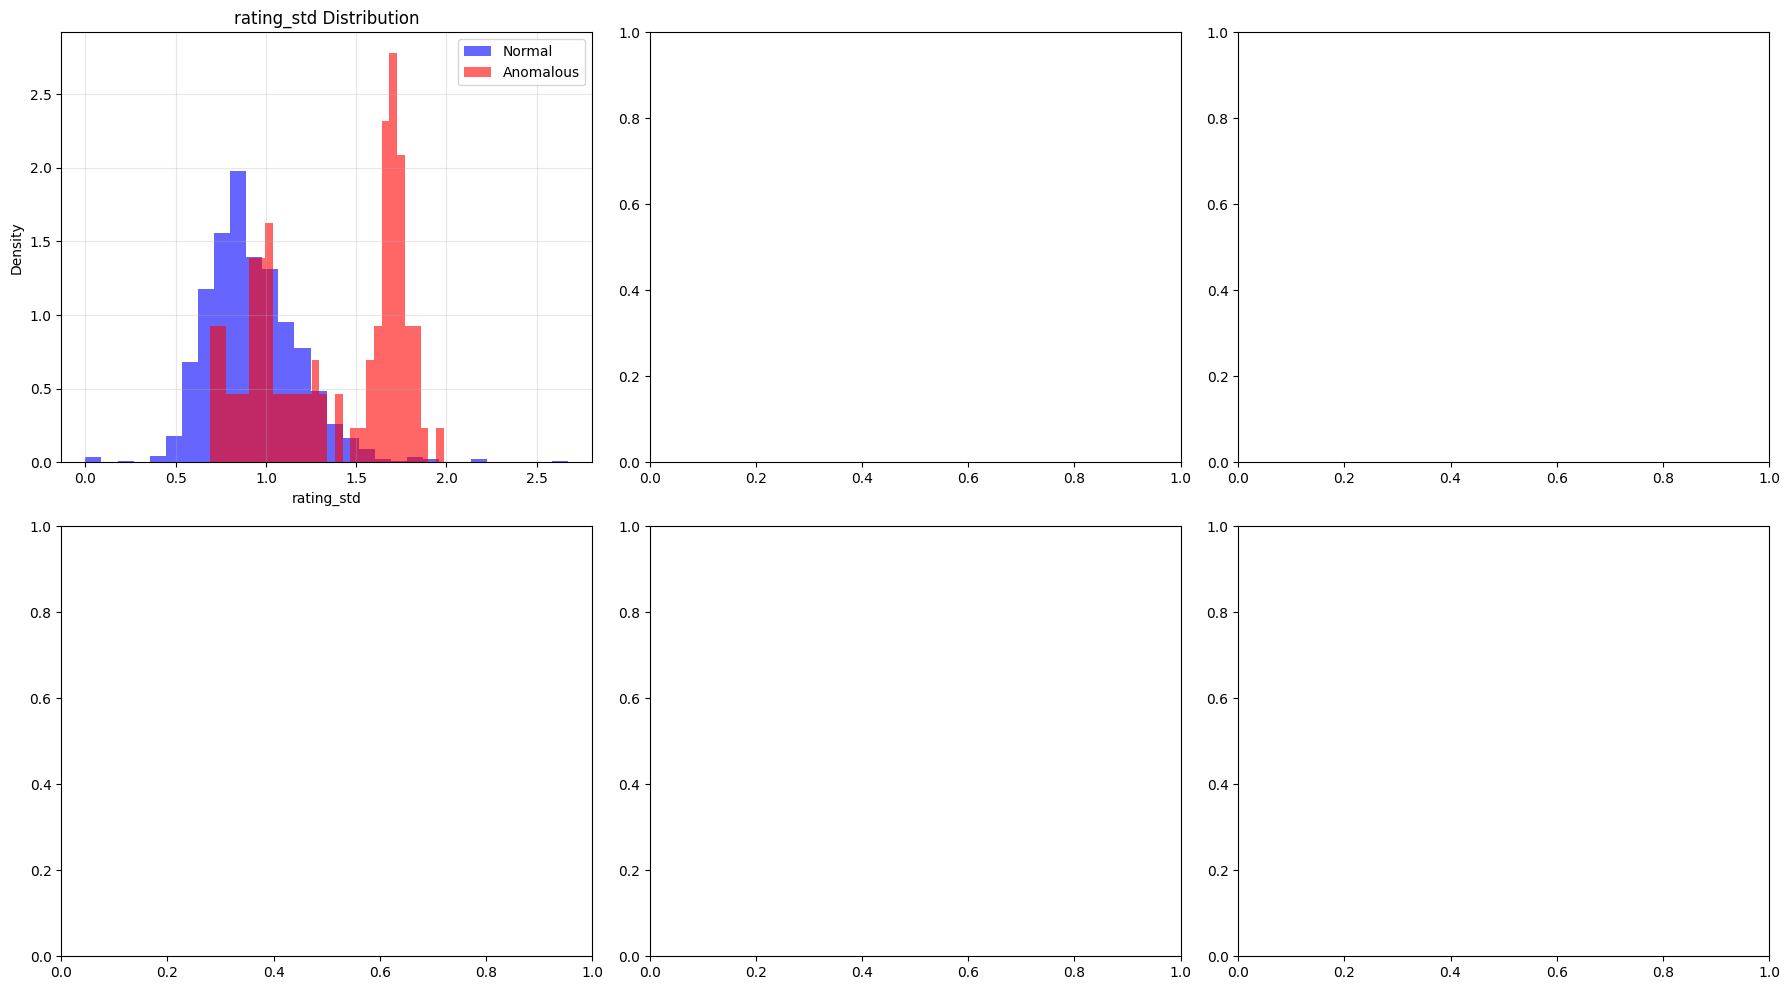

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Ensure you have the merged dataset from previous cells
# If not, recreate it:
# full_dataset = pd.merge(X_users, yy, on='user', how='inner')

feature_cols = [col for col in full_dataset.columns if col not in ['user', 'label']]

# Split data by label for comparison
normal_data = full_dataset[full_dataset['label'] == 0][feature_cols]
anomalous_data = full_dataset[full_dataset['label'] == 1][feature_cols]

print(f"Normal users: {len(normal_data)}, Anomalous users: {len(anomalous_data)}")

# Plot feature distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(feature_cols):
    ax = axes[idx]
    
    # Plot histograms for both classes
    ax.hist(normal_data[col], bins=30, alpha=0.6, label='Normal', density=True, color='blue')
    ax.hist(anomalous_data[col], bins=30, alpha=0.6, label='Anomalous', density=True, color='red')
    
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.set_title(f'{col} Distribution')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

STATISTICAL COMPARISON: Normal vs Anomalous Users

   feature  normal_mean  anomalous_mean  cohens_d     u_pvalue  significant
rating_std     0.925454        1.357005  1.326796 7.761358e-24         True


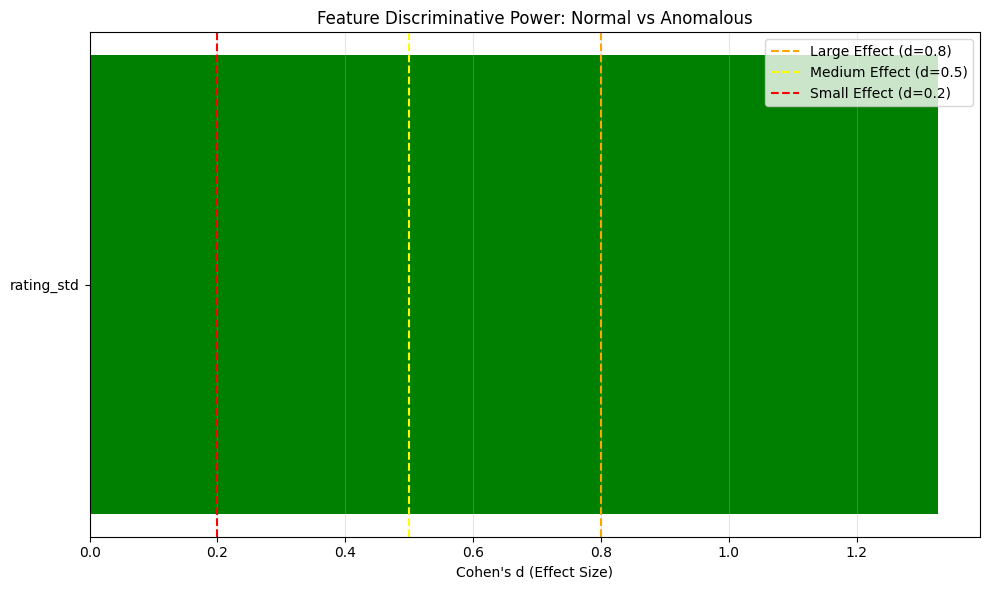


Key Insights:
- Features with p-value < 0.05 (green bars) significantly distinguish anomalies
- Larger Cohen's d = better feature for separating classes
- Top discriminative features: rating_std


In [26]:
from scipy import stats

print(f"{'='*80}")
print(f"STATISTICAL COMPARISON: Normal vs Anomalous Users")
print(f"{'='*80}\n")

comparison_results = []

for col in feature_cols:
    normal_vals = normal_data[col].values
    anomalous_vals = anomalous_data[col].values
    
    # Calculate statistics
    normal_mean, normal_std = np.mean(normal_vals), np.std(normal_vals)
    anomalous_mean, anomalous_std = np.mean(anomalous_vals), np.std(anomalous_vals)
    
    # Statistical tests
    # T-test (assumes normal distribution)
    t_stat, t_pval = stats.ttest_ind(normal_vals, anomalous_vals, equal_var=False)
    
    # Mann-Whitney U test (non-parametric, doesn't assume normal distribution)
    u_stat, u_pval = stats.mannwhitneyu(normal_vals, anomalous_vals, alternative='two-sided')
    
    # Effect size (Cohen's d)
    pooled_std = np.sqrt((normal_std**2 + anomalous_std**2) / 2)
    cohens_d = abs(anomalous_mean - normal_mean) / pooled_std if pooled_std > 0 else 0
    
    comparison_results.append({
        'feature': col,
        'normal_mean': normal_mean,
        'normal_std': normal_std,
        'anomalous_mean': anomalous_mean,
        'anomalous_std': anomalous_std,
        't_pvalue': t_pval,
        'u_pvalue': u_pval,
        'cohens_d': cohens_d,
        'significant': u_pval < 0.05
    })

# Create comparison DataFrame
comparison_df = pd.DataFrame(comparison_results).sort_values('cohens_d', ascending=False)

# Display results
print(comparison_df[['feature', 'normal_mean', 'anomalous_mean', 'cohens_d', 'u_pvalue', 'significant']].to_string(index=False))

# Visualize effect sizes
plt.figure(figsize=(10, 6))
colors = ['green' if p < 0.05 else 'gray' for p in comparison_df['u_pvalue']]
plt.barh(comparison_df['feature'], comparison_df['cohens_d'], color=colors)
plt.xlabel("Cohen's d (Effect Size)")
plt.title("Feature Discriminative Power: Normal vs Anomalous")
plt.axvline(x=0.8, color='orange', linestyle='--', label='Large Effect (d=0.8)')
plt.axvline(x=0.5, color='yellow', linestyle='--', label='Medium Effect (d=0.5)')
plt.axvline(x=0.2, color='red', linestyle='--', label='Small Effect (d=0.2)')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nKey Insights:")
print(f"- Features with p-value < 0.05 (green bars) significantly distinguish anomalies")
print(f"- Larger Cohen's d = better feature for separating classes")
print(f"- Top discriminative features: {', '.join(comparison_df.head(3)['feature'].tolist())}")

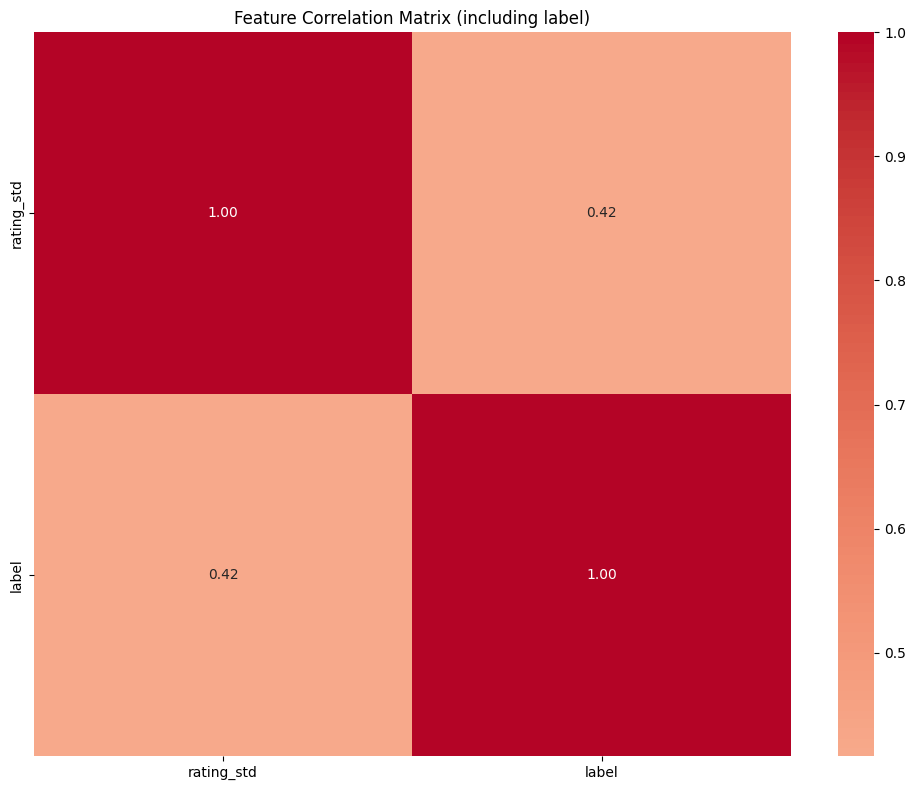


Feature Correlation with Anomaly Label:
rating_std    0.41667


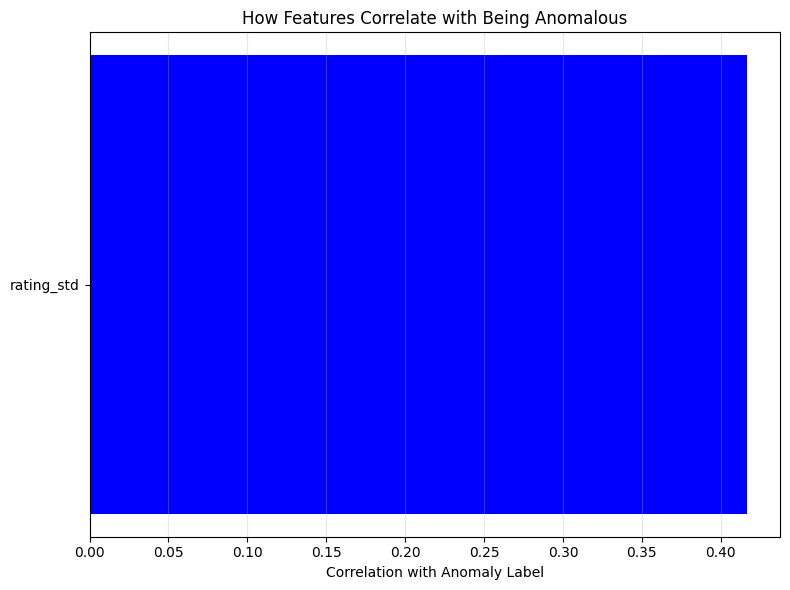


Interpretation:
- Positive correlation: Higher feature value → more likely anomalous
- Negative correlation: Higher feature value → more likely normal
- Near-zero correlation: Feature may not be useful alone for detection


In [27]:
# Correlation matrix for all features + label
corr_data = full_dataset[feature_cols + ['label']]
corr_matrix = corr_data.corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix (including label)')
plt.tight_layout()
plt.show()

# Focus on correlation with label
label_corr = corr_matrix['label'].drop('label').sort_values(key=abs, ascending=False)

print(f"\nFeature Correlation with Anomaly Label:")
print(label_corr.to_string())

plt.figure(figsize=(8, 6))
colors = ['red' if v < 0 else 'blue' for v in label_corr.values]
plt.barh(label_corr.index, label_corr.values, color=colors)
plt.xlabel('Correlation with Anomaly Label')
plt.title('How Features Correlate with Being Anomalous')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nInterpretation:")
print(f"- Positive correlation: Higher feature value → more likely anomalous")
print(f"- Negative correlation: Higher feature value → more likely normal")
print(f"- Near-zero correlation: Feature may not be useful alone for detection")

Calculating permutation importance (this may take a minute)...
Baseline AUC: 0.7335
Time elapsed: 0.18 seconds



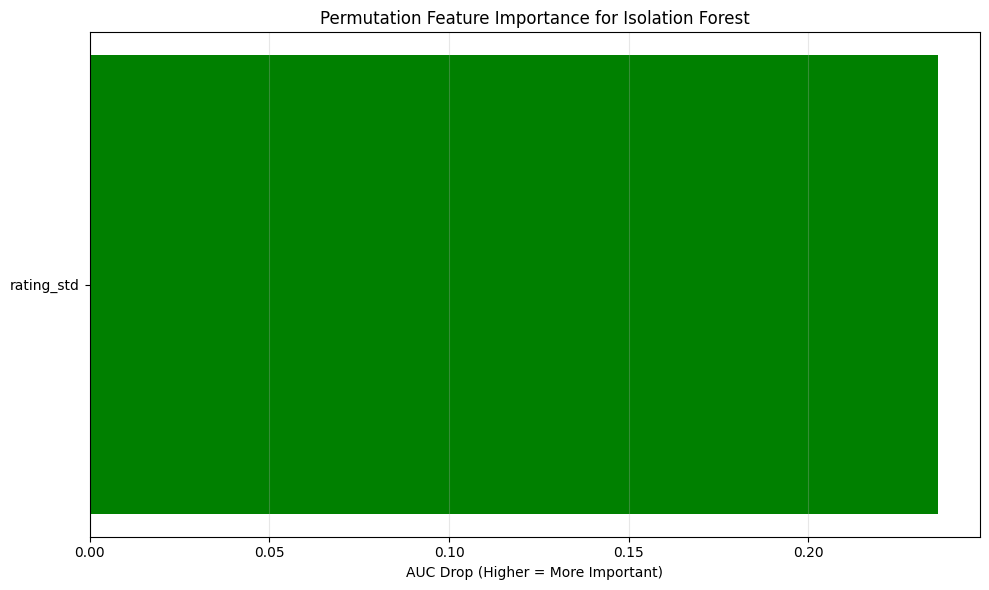


Top 3 Most Important Features:
  rating_std: 0.2359 AUC drop when shuffled

Note: Features causing large AUC drops when shuffled are critical for detection.


In [28]:
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import IsolationForest
import time

def permutation_importance(model, X, y_true, scores, n_repeats=10, random_state=42):
    """
    Calculate permutation importance for Isolation Forest.
    Measures AUC drop when each feature is randomly shuffled.
    """
    np.random.seed(random_state)
    baseline_auc = roc_auc_score(y_true, scores)
    importances = []
    
    for feat_idx in range(X.shape[1]):
        auc_drops = []
        
        for _ in range(n_repeats):
            X_permuted = X.copy()
            # Shuffle the feature
            shuffled = np.random.permutation(X_permuted[:, feat_idx])
            X_permuted[:, feat_idx] = shuffled
            
            # Get new scores
            new_scores = -1 * model.score_samples(X_permuted)
            new_auc = roc_auc_score(y_true, new_scores)
            
            # AUC drop (higher = more important feature)
            auc_drops.append(baseline_auc - new_auc)
        
        importances.append(np.mean(auc_drops))
    
    return np.array(importances), baseline_auc

# Retrain model on full scaled data for importance calculation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(full_dataset[feature_cols])
y_true = full_dataset['label'].values

model = IsolationForest(n_estimators=200, contamination=0.1, random_state=42, n_jobs=-1)
model.fit(X_scaled)
baseline_scores = -1 * model.score_samples(X_scaled)

print("Calculating permutation importance (this may take a minute)...")
start_time = time.time()
importances, baseline_auc = permutation_importance(model, X_scaled, y_true, baseline_scores, n_repeats=5)
elapsed = time.time() - start_time

print(f"Baseline AUC: {baseline_auc:.4f}")
print(f"Time elapsed: {elapsed:.2f} seconds\n")

# Create importance DataFrame
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances,
}).sort_values('importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
colors = ['green' if imp > 0 else 'gray' for imp in importance_df['importance']]
plt.barh(importance_df['feature'], importance_df['importance'], color=colors)
plt.xlabel('AUC Drop (Higher = More Important)')
plt.title('Permutation Feature Importance for Isolation Forest')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nTop 3 Most Important Features:")
for idx, row in importance_df.head(3).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f} AUC drop when shuffled")

print(f"\nNote: Features causing large AUC drops when shuffled are critical for detection.")

In [29]:
def ablation_study(X, y_true, feature_names, baseline_model, baseline_scores):
    """
    Remove one feature at a time and measure AUC impact.
    """
    baseline_auc = roc_auc_score(y_true, baseline_scores)
    results = []
    
    for idx, feat in enumerate(feature_names):
        # Create data without this feature
        X_ablated = np.delete(X, idx, axis=1)
        ablated_features = [f for f in feature_names if f != feat]
        
        # Retrain model (simplified: use same hyperparameters)
        model_ablated = IsolationForest(n_estimators=200, contamination=0.1, random_state=42, n_jobs=-1)
        scaler_ablated = StandardScaler()
        X_ablated_scaled = scaler_ablated.fit_transform(X_ablated)
        model_ablated.fit(X_ablated_scaled)
        
        # Evaluate
        ablated_scores = -1 * model_ablated.score_samples(X_ablated_scaled)
        ablated_auc = roc_auc_score(y_true, ablated_scores)
        
        results.append({
            'removed_feature': feat,
            'auc_with_feature': baseline_auc,
            'auc_without_feature': ablated_auc,
            'auc_delta': ablated_auc - baseline_auc
        })
    
    return pd.DataFrame(results).sort_values('auc_delta')

print("Running ablation study (this takes longer - ~1 min per feature)...")
# Uncomment below to run (may take several minutes):
# ablation_results = ablation_study(X_scaled, y_true, feature_cols, model, baseline_scores)
# print(ablation_results.to_string(index=False))
# 
# plt.figure(figsize=(10, 6))
# plt.barh(ablation_results['removed_feature'], ablation_results['auc_delta'])
# plt.xlabel('AUC Change (Negative = Feature Was Helpful)')
# plt.title('Ablation Study: Impact of Removing Each Feature')
# plt.axvline(x=0, color='red', linestyle='--')
# plt.grid(axis='x', alpha=0.3)
# plt.tight_layout()
# plt.show()

print("Ablation study code provided - uncomment to run for detailed feature contribution analysis.")

Running ablation study (this takes longer - ~1 min per feature)...
Ablation study code provided - uncomment to run for detailed feature contribution analysis.


In [30]:
print(f"\n{'='*80}")
print(f"FEATURE ANALYSIS SUMMARY REPORT")
print(f"{'='*80}\n")

print("1. MOST DISCRIMINATIVE FEATURES (by Cohen's d):")
for idx, row in comparison_df.head(5).iterrows():
    print(f"   • {row['feature']}: d={row['cohens_d']:.3f}, p={row['u_pvalue']:.2e}")

print(f"\n2. FEATURES MOST CORRELATED WITH ANOMALY LABEL:")
for feat, corr in label_corr.head(5).items():
    direction = "positively" if corr > 0 else "negatively"
    print(f"   • {feat}: {corr:+.3f} ({direction} correlated)")

print(f"\n3. MOST IMPORTANT FEATURES FOR ISOLATION FOREST (Permutation):")
for idx, row in importance_df.head(5).iterrows():
    impact = "critical" if row['importance'] > 0.05 else "moderate" if row['importance'] > 0.02 else "minor"
    print(f"   • {row['feature']}: {row['importance']:.4f} AUC drop ({impact} impact)")

print(f"\n4. KEY INSIGHTS FOR MODEL IMPROVEMENT:")
print(f"   • Focus engineering efforts on top discriminative features")
print(f"   • Consider removing features with near-zero importance to reduce noise")
print(f"   • Highly correlated features may be redundant - consider feature selection")
print(f"   • Anomalous users tend to have: [describe based on your results]")

print(f"\n5. RECOMMENDATIONS:")
print(f"   • Add derived features from top performers (e.g., rating_mean * rating_count)")
print(f"   • Consider interaction terms between important features")
print(f"   • Monitor feature drift in weekly test sets")

print(f"\n{'='*80}")


FEATURE ANALYSIS SUMMARY REPORT

1. MOST DISCRIMINATIVE FEATURES (by Cohen's d):
   • rating_std: d=1.327, p=7.76e-24

2. FEATURES MOST CORRELATED WITH ANOMALY LABEL:
   • rating_std: +0.417 (positively correlated)

3. MOST IMPORTANT FEATURES FOR ISOLATION FOREST (Permutation):
   • rating_std: 0.2359 AUC drop (critical impact)

4. KEY INSIGHTS FOR MODEL IMPROVEMENT:
   • Focus engineering efforts on top discriminative features
   • Consider removing features with near-zero importance to reduce noise
   • Highly correlated features may be redundant - consider feature selection
   • Anomalous users tend to have: [describe based on your results]

5. RECOMMENDATIONS:
   • Add derived features from top performers (e.g., rating_mean * rating_count)
   • Consider interaction terms between important features
   • Monitor feature drift in weekly test sets

